# [기초-실습] 통계 101×데이터 분석: (4장) 추론통계~신뢰구간

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

from matplotlib import rc
rc('font', family='NanumMyeongjo')
rc('axes', unicode_minus=False)

'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'sudo'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'NanumMyeongjo'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 문제 1. 표본조사 체험하기

**📘 문제**

- 온라인 쇼핑몰은 전체 고객 수가 너무 많아, 모든 고객을 조사하기 어렵습니다.

- 그래서 무작위로 고객 30명을 뽑아 평균 만족도를 계산하고 이를 전체 만족도의 추정값으로 사용하려 합니다.

- 이번 실습에서는 직접 표본을 뽑고, 표본 평균을 구해보며,
  **“표본마다 결과가 달라질 수 있다”**는 추론 통계의 핵심 개념을 체험해봅니다.

findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font family 'NanumMyeongjo' not found.
findfont: Font famil

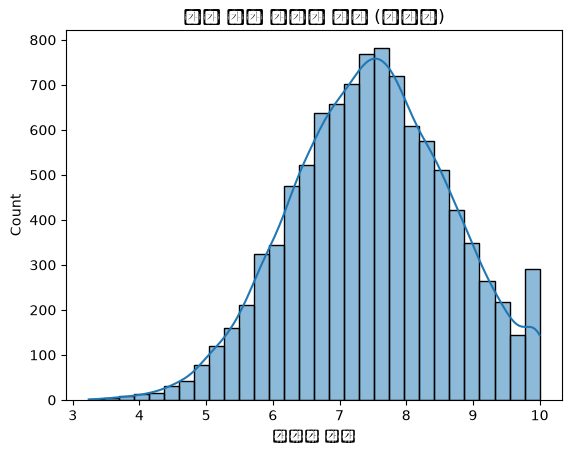

In [3]:
# 모집단 생성 (전체 고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.5, scale=1.2, size=10000)
population = np.clip(population, 1, 10)  # 1점 ~ 10점 사이로 제한
df_pop = pd.DataFrame({'score': population})

# 전체 모집단 시각화
sns.histplot(df_pop['score'], bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 표본을 무작위로 여러 번 뽑아 보고, 표본 평균이 어떻게 변하는지 확인해봅시다.

- 히스토그램을 그리고, 표본 평균의 분포 형태를 관찰해봅시다.

In [4]:
# [문제 1] Q1. 모집단에서 무작위로 30명을 뽑아 표본 평균을 구해봅시다.
np.random.seed(2025)

sample = np.random.choice(population, size=30, replace=False)
sample_mean = sample.mean()

print("표본:", sample)
print("표본 평균:", sample_mean)

표본: [7.15007966 7.7393484  7.03293945 7.91313711 6.93951644 5.65084442
 7.43005279 7.17356319 6.88374833 6.96786101 8.52459225 9.82814791
 7.77402127 7.08677594 5.55729163 7.10447556 8.16102197 7.92354825
 8.13035687 7.51814866 5.91074111 8.03647362 7.84949589 7.27527683
 7.52154547 8.28112575 9.0735261  5.85709349 6.91310297 6.93441453]
표본 평균: 7.404742229332289


In [5]:
# [문제 1] Q2. 이 과정을 500번 반복하고, 표본 평균을 리스트에 저장합니다.
np.random.seed(2025)

sample_means = []

for _ in range(500):
    sample = np.random.choice(population, size=30, replace=False)
    sample_mean = sample.mean()
    sample_means.append(sample_mean)

print("전체 반복 횟수:", len(sample_means))
print("1번째 표본평균:", sample_means[0])
print("500번째 표본평균:", sample_means[-1])
print("전체 리스트:", sample_means)

전체 반복 횟수: 500
1번째 표본평균: 7.404742229332289
500번째 표본평균: 7.180720338724175
전체 리스트: [np.float64(7.404742229332289), np.float64(7.701406541303069), np.float64(7.334755612071231), np.float64(7.575267003846345), np.float64(7.646782651114237), np.float64(7.273462551326532), np.float64(7.421399243043869), np.float64(7.453924233422445), np.float64(7.68852275076122), np.float64(7.601368972387283), np.float64(7.20557395292238), np.float64(7.022036487163065), np.float64(7.5339688466594685), np.float64(7.205268560076575), np.float64(7.3142084393330675), np.float64(7.747411413860209), np.float64(7.332953931860411), np.float64(7.800057912706262), np.float64(7.530470369072374), np.float64(7.7114171407072964), np.float64(7.28409216325463), np.float64(7.5065744804083145), np.float64(7.589710883013153), np.float64(7.259820138089935), np.float64(7.56486518172912), np.float64(7.5769415155292545), np.float64(7.681181795527404), np.float64(7.607566318152822), np.float64(7.420179981022191), np.float64(7.664009

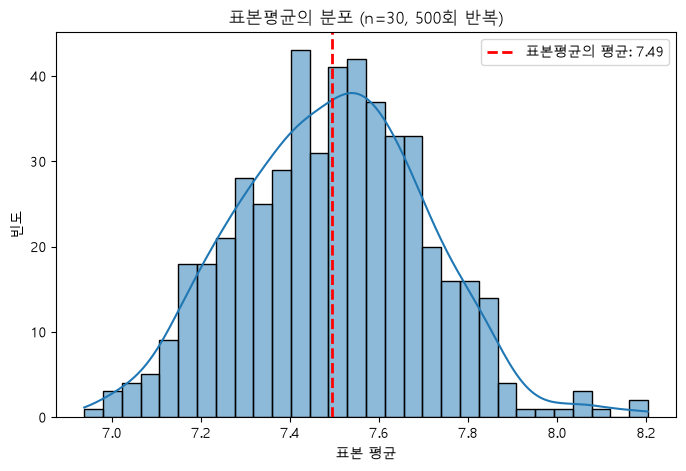

In [6]:
# [문제 1] Q3. 표본 평균들의 분포를 히스토그램으로 그려봅시다. 평균선도 함께 표시해 봅시다.
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

sample_means = np.array(sample_means)

plt.figure(figsize=(8, 5))
sns.histplot(sample_means, bins=30, kde=True)
plt.axvline(sample_means.mean(), color='red', linestyle='--', linewidth=2,
            label=f'표본평균의 평균: {sample_means.mean():.2f}')
plt.title("표본평균의 분포 (n=30, 500회 반복)")
plt.xlabel("표본 평균")
plt.ylabel("빈도")
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 평균들은 어떤 값 주변에 많이 분포해 있나요? 이 값은 전체 모집단 평균과 얼마나 비슷한가요?

- 표본을 1번 뽑았을 때와 500번을 반복해서 뽑았을 때, 표본 평균의 분포나 신뢰성에는 어떤 차이가 있나요

- 친구가 다른 표본을 뽑았다면 같은 평균이 나왔을까요? 비슷한 결과가 나왔더라도 완전히 같지 않았다면, 그 이유는 무엇일까요?

- 표본 평균들의 분포는 어떤 모양인가요? 종 모양의 정규분포처럼 보이나요? 그렇다면 왜 그렇게 되는 걸까요?

In [7]:
# [문제 1] 데이터를 어떻게 읽을까요?

# 표본 평균의 평균은 7.49로 모집단의 실제 평균값과 유사해보임

# 표본을 1번만 뽑았을 때는 그 표본평균이 우연히 모집단 평균보다 높거나 낮을 수 있다.
# 예를 들어 우연히 만족도 높은 사람들만 30명이 뽑히면 표본 평균이 실제 모평균보다
# 훨씬 높게 나올 수 있습니다.

# 그러나 500번을 반복해서 뽑았을 떄는 이러한 우연들이 서로 상쇄되면서 전체적으로 모평균 주변에
# 몰리는 패턴이 발생합니다. 이를 통해 신뢰성은 훨씬 높아지ㄱ, 추가적으로 표본 평균이 얼마나
# 흩어져 있는지도 확인이가능해 이 추정이 얼마나 안정적인지를 판단할 수 있습니다.

# 친구가 다른 표본을 뽑아도 정확히 같은 값은 나오지 않을 가능성이 큽니다.
# 30명을 무작위로 뽑는 과정 자체가 매번 다르기 때문이죠.
# 완전히 같지 않아도 비슷한 결과가 나올 수 있는 이유는 모집단 자체가
# 어떠한 특정 평균과 표준편차를 가진 분포를 따르기 때문입니다.

# 표본평균들의 분포는 종모양의 정규분포와 유사하게 보입니다.
# 중심극한정리 때문인데요, 모집단의 분포 모양과 상관없이, 표본의 크기가 충분히 크면
# 표본평균의 분포가 정규분포에 가까워지기 때문입니다.

# 문제 2. 중심극한정리

**📘 문제**

- 현실에서는 모집단의 분포가 정규분포가 아닐 수도 있습니다.

- 예를 들어, 일부 고객은 매우 높은 점수를 주고, 대부분은 낮은 점수를 주는 만족도 분포가 있을 수 있죠. (예: 지수분포)

- 이처럼 원래 분포가 비정규분포여도,
  표본을 여러 번 뽑아 평균을 계산하면, 그 평균들의 분포는 정규분포에 가까워진다는 것을
  **중심극한정리(Central Limit Theorem)**라고 합니다.

- 이번 실습에서는 다양한 크기의 표본을 뽑아 평균을 계산하고,
  그 평균들의 분포가 어떻게 변하는지를 직접 실험해 봅니다.

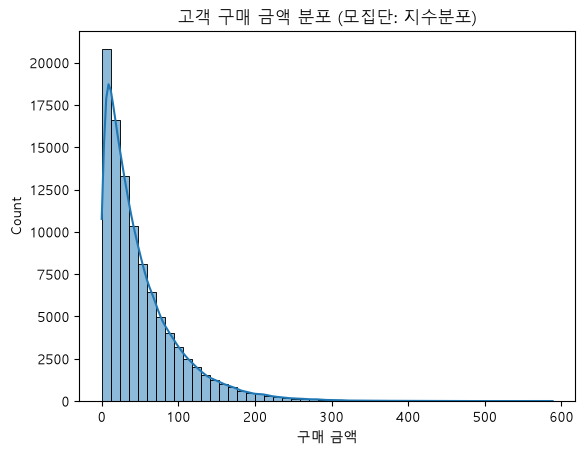

In [8]:
# 지수분포를 따르는 모집단 생성
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)  # 평균 50, 비대칭 분포

# 모집단 시각화
sns.histplot(population, bins=50, kde=True)
plt.title("고객 구매 금액 분포 (모집단: 지수분포)")
plt.xlabel("구매 금액")
plt.show()

**📌 아래를 수행해 보세요:**

- 비대칭적인 모집단(지수분포)에서 무작위로 표본을 추출해 평균을 구해봅시다.

- 표본 크기를 바꿔가며, 표본 평균들의 분포가 어떻게 변화하는지 확인해봅시다.

- 히스토그램을 그리고, 분포의 모양을 관찰해봅시다.

- 표본 크기가 커질수록 표본 평균 분포의 모양과 **퍼진 정도(분산)**가 어떻게 변하는지 관찰해봅시다.

In [9]:
# [문제 2] Q1. 모집단에서 표본을 1000번 뽑고, 각 표본의 평균을 구해봅시다.
# 표본 크기 = 5일 때

np.random.seed(2025)

sample_size = 5
sample_means_5 = []

for _ in range(1000):
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_mean = sample.mean()
    sample_means_5.append(sample_mean)

sample_means_5 = np.array(sample_means_5)

print("반복 횟수:", len(sample_means_5))
print("표본평균들의 평균:", sample_means_5.mean())

반복 횟수: 1000
표본평균들의 평균: 49.56468832083199


In [10]:
# [문제 2] Q2. 위 과정을 표본 크기 30, 100일 때도 반복해봅시다.
# sample_size = 30, 100

np.random.seed(2025)

# 표본 크기 30
sample_size = 30
sample_means_30 = []

for _ in range(1000):
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_mean = sample.mean()
    sample_means_30.append(sample_mean)

sample_means_30 = np.array(sample_means_30)

print("[n=30] 표본평균들의 평균:", sample_means_30.mean())

# 표본 크기 100
sample_size = 100
sample_means_100 = []

for _ in range(1000):
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_mean = sample.mean()
    sample_means_100.append(sample_mean)

sample_means_100 = np.array(sample_means_100)

print("[n=100] 표본평균들의 평균:", sample_means_100.mean())

[n=30] 표본평균들의 평균: 49.657822224723496
[n=100] 표본평균들의 평균: 50.28390438569289


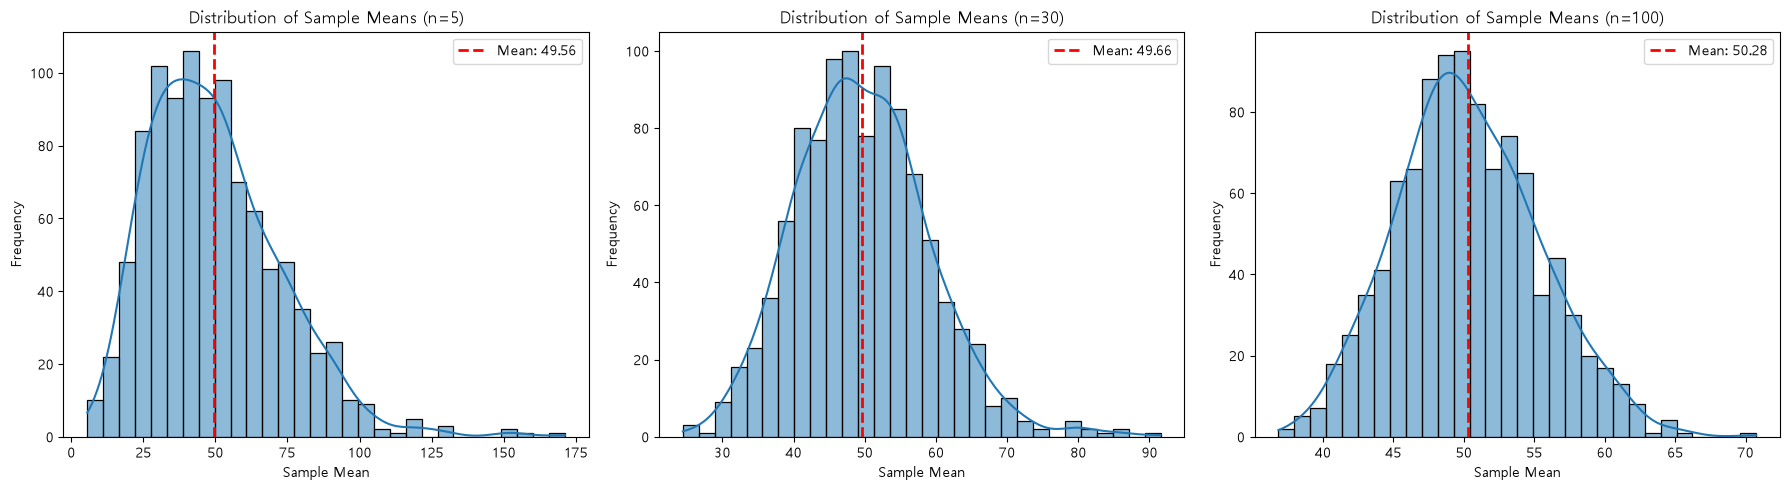

In [11]:
# [문제 2] Q3. 각 표본 크기별로 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 평균선을 함께 표시해 봅시다.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample_means_list = [sample_means_5, sample_means_30, sample_means_100]
sample_sizes = [5, 30, 100]

for ax, means, n in zip(axes, sample_means_list, sample_sizes):
    sns.histplot(means, bins=30, kde=True, ax=ax)
    ax.axvline(means.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {means.mean():.2f}')
    ax.set_title(f"Distribution of Sample Means (n={n})")
    ax.set_xlabel("Sample Mean")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을 때 (예: 5), 평균들의 분포는 어떤 모양인가요?

- 표본 크기가 커질수록 평균 분포의 모양은 어떤 변화를 보이나요?

- 원래 모집단은 비대칭이었는데, 왜 평균들의 분포는 정규분포처럼 바뀌었을까요?

- 이 실험을 통해 중심극한정리를 어떻게 이해하게 되었나요?

- 표본 크기에 따라 **분포의 넓이(흩어짐)**는 어떻게 달라지나요?

In [12]:
# [문제 2]데이터를 어떻게 읽을까요?

# 표본의 크기가 작을 때 평균들의 분포는 오른쪽으로 꼬리가 긴 치우친 분포를 하고 있습니다.
# 원래 모집단의 분포가 지수분포를 따르고 있기 떄문이죠

# 표본의 크기가 커질수록 비대칭이 오나화되면서 점점 정규분포의 모양을 띄게 됩니다.
# 이게 바로 중심극한정리의 핵심입니다. 5번만 뽑으면 우연히 극단값 하나가 평균을 크게 흔들지만
# 표본의 크기가 충분히 커지면 여러 표본 평균들이 서로 상쇄되면서 평균적인 값에 수렵합니다.

# 표본의 크기가 커질수록 분포의 폭도 점점 좁아집니다. 
# 이건 표준오차 공식 때문입니다. 표준오차의 분모는 표본의 개수이기 떄문에
# 분모가 커질 수록 표준오차는 점점 작아지고 그렇다는 것은 표본 평균들이 모집단 평균 주변에
# 더 촘촘하게 모이게 됩니다. 

# 문제 3. 표준오차

**📘 문제**

- 앞선 실습에서 우리는 **표본 크기(n)가 커질수록 표본 평균들의 분포가 더 좁아진다**는 것을 확인했습니다.
- 이처럼 표본 평균들이 얼마나 흩어져 있는지(분포의 퍼진 정도)를 나타내는 값을 **표준오차(Standard Error, SE)**라고 부릅니다.
- 표준오차는 **표본 평균들의 표준편차**와 같은 의미이며, 이는 우리가 뽑은 표본 평균이 실제 모평균과 평균적으로 얼마나 떨어져 있을지를 나타내는 **'예상 오차의 크기'**입니다.

- 통계학적으로 이 표준오차는 **`SE = σ / √n`** (모집단 표준편차 / 표본 크기의 제곱근) 이라는 공식으로 계산할 수 있습니다.
- 이 공식은 **표본 크기(n)가 커질수록 표준오차(SE)가 작아진다**는 것을 명확히 보여줍니다.

- 이번 실습에서는 여러 크기의 표본을 뽑아, 시뮬레이션을 통해 얻은 **표본 평균들의 표준편차(실험값)**가 공식으로 계산한 **표준오차(이론값)**와 얼마나 일치하는지 직접 확인해봅니다.

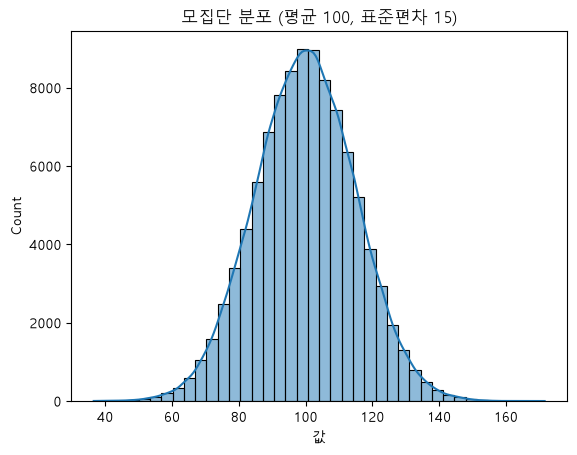

In [13]:
# 모집단 생성 (평균 100, 표준편차 15)
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 여러 크기의 표본(10, 30, 100, 500)을 각각 1000번 뽑고, 그 평균들을 구한 뒤, **표본 평균들의 표준편차(=실험적 표준오차)**를 계산해봅시다.

- 이 결과를 이론적인 표준오차 공식과 비교하는 표를 만들고, 시각화해봅시다.

In [14]:
# [문제 3] Q1. 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본을 뽑고, 평균을 구해봅시다.
# 각 표본 평균 분포의 표준편차를 계산해봅시다.
# 결과를 리스트에 저장하고, 표로 정리해봅시다.

np.random.seed(2025)

sample_sizes = [10, 30, 100, 500]
sample_means_dict = {}
empirical_std_list = []

for n in sample_sizes:
    means = []
    for _ in range(1000):
        sample = np.random.choice(population, size=n, replace=False)
        means.append(sample.mean())
    means = np.array(means)
    sample_means_dict[n] = means
    empirical_std_list.append(means.std())

# 결과 표로 정리
df_result = pd.DataFrame({
    'sample_size': sample_sizes,
    'empirical_std': empirical_std_list
})

print(df_result)

   sample_size  empirical_std
0           10       4.558660
1           30       2.746502
2          100       1.492328
3          500       0.653220


In [15]:
# [문제 3] Q2. 이론적인 표준오차와 비교해봅시다.
# [공식] 표준오차(SE) = 모집단 표준편차 / √표본크기

population_std = population.std()

theoretical_se_list = [population_std / np.sqrt(n) for n in sample_sizes]

df_result['theoretical_se'] = theoretical_se_list
df_result['difference'] = df_result['empirical_std'] - df_result['theoretical_se']

print(df_result)

   sample_size  empirical_std  theoretical_se  difference
0           10       4.558660        4.753921   -0.195261
1           30       2.746502        2.744677    0.001825
2          100       1.492328        1.503322   -0.010994
3          500       0.653220        0.672306   -0.019086


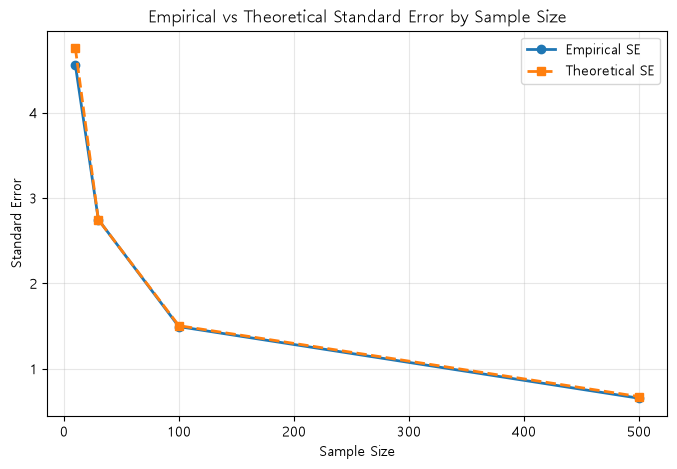

In [16]:
# [문제 3] Q3. 실험값과 이론값을 시각화해봅시다.
# 표본 크기를 x축, 표준오차를 y축으로 한 꺾은선 그래프를 그려봅시다.

plt.figure(figsize=(8, 5))

plt.plot(df_result['sample_size'], df_result['empirical_std'], marker='o', label='Empirical SE', linewidth=2)
plt.plot(df_result['sample_size'], df_result['theoretical_se'], marker='s', linestyle='--', label='Theoretical SE', linewidth=2)

plt.title("Empirical vs Theoretical Standard Error by Sample Size")
plt.xlabel("Sample Size")
plt.ylabel("Standard Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요?

- 표본 크기가 커질수록, 평균 분포는 어떻게 변하나요?

- 실험값과 이론값(공식 계산값)은 얼마나 비슷한가요?

- 왜 표본 크기가 커질수록 표준오차는 작아질까요?

In [17]:
# [문제 3] 데이터를 어떻게 읽을까요?

# n=10일 때 empirical_std = 4.56로, 다른 표본 크기들에 비해 훨씬 큰 값을 보입니다. 
# 표준편차가 크다는 건 표본평균들이 서로 많이 다르게 나온다는 뜻이니, 
# 이 경우 분포가 넓게 퍼진 형태로 나타납니다

# 표준오차(SE = σ/√n) 공식을 보면 분모에 √n이 있기 때문에, 
# n이 커질수록 SE는 작아집니다. 

# difference 열을 보면 실험값(empirical_std)과 
# 이론값(theoretical_se)의 차이가 매우 작습니다.

# 표본의 크기가 커질수록 표준오차가 작아지는 이유는 극단값들이 서로 상쇄되기 때문입니다.
# 표본 크기가 작을 때는 우연히 극단적인 값(아주 높거나 낮은 값)이 여러 개 포함될 가능성이 
# 꽤 있습니다. 소수의 값이 전체 평균에 미치는 영향력이 크죠.
# 표본 크기가 클 때는 극단적으로 높은 값과 낮은 값들이 골고루 섞여 들어갈 확률이 높아서
# 한두 개의 극단값이 있어도 나머지 값들에 의해 영향이 희석(평균화)됩니다.

# 문제 4. 신뢰구간 계산과 해석

**📘 문제**

- 표본 평균은 모집단 평균을 추정하는 좋은 점 추정(Point Estimation) 값이지만, 표본오차 때문에 정확히 일치하지는 않습니다.

- 그래서 우리는 "모집단 평균이 아마 이 범위 안에 있을 것이다"라고 **구간으로 추정(Interval Estimation)**하는 것이 더 합리적입니다. 이때 사용하는 개념이 바로 **신뢰구간(Confidence Interval)**입니다.

- 신뢰구간은 표본평균 ± 오차범위 형태로 계산되며, 이 오차범위는 신뢰수준(예: 95%, 99%)과 표본오차에 의해 결정됩니다.

- 이번 실습에서는 **모집단 표준편차(σ)를 알 때(z-분포)**와 **모를 때(t-분포)**의 신뢰구간을 각각 계산해보고, 신뢰수준에 따라 구간의 폭이 어떻게 변하는지 확인해봅니다.

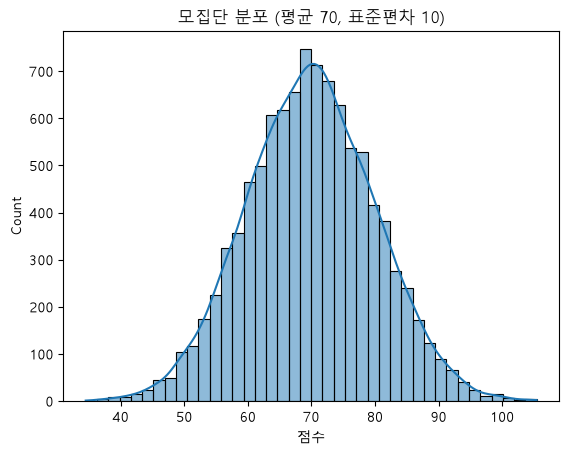

In [18]:
# 모집단 생성
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 70, 표준편차 10)")
plt.xlabel("점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 30명을 무작위로 뽑아 평균, 표준편차, 표준오차를 계산해보세요.

- 95% 신뢰구간을 z-분포와 t-분포를 각각 사용해서 계산해보세요.

- 신뢰수준을 바꿨을 때(90%, 99%) 신뢰구간이 어떻게 변하는지 확인해보세요.

In [19]:
# [문제 4] Q1. 모집단에서 표본 30명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 표준오차도 함께 계산해보세요.

np.random.seed(2025)

n = 30
sample = np.random.choice(population, size=n, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)  # 표본표준편차 (자유도 n-1)
standard_error = sample_std / np.sqrt(n)

print("표본 평균:", sample_mean)
print("표본 표준편차:", sample_std)
print("표준오차(SE):", standard_error)

표본 평균: 69.20618524443573
표본 표준편차: 7.875499169121773
표준오차(SE): 1.4378628488470628


In [20]:
# [문제 4] Q2. 모집단의 표준편차를 알고 있다고 가정하고, z-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

from scipy import stats

population_std = population.std()  # 모집단 표준편차 (알고 있다고 가정)
se_known = population_std / np.sqrt(n)

confidence = 0.95
z_critical = stats.norm.ppf((1 + confidence) / 2)

margin_of_error_z = z_critical * se_known
ci_lower_z = sample_mean - margin_of_error_z
ci_upper_z = sample_mean + margin_of_error_z

print("z-critical 값:", z_critical)
print(f"95% 신뢰구간 (z-분포): ({ci_lower_z:.2f}, {ci_upper_z:.2f})")

z-critical 값: 1.959963984540054
95% 신뢰구간 (z-분포): (65.63, 72.79)


In [21]:
# [문제 4] Q3. 모집단의 표준편차를 모른다고 가정하고, 표본 표준편차와 t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

df = n - 1  # 자유도
t_critical = stats.t.ppf((1 + confidence) / 2, df=df)

margin_of_error_t = t_critical * standard_error  # Q1에서 구한 표본 기반 표준오차 사용
ci_lower_t = sample_mean - margin_of_error_t
ci_upper_t = sample_mean + margin_of_error_t

print("t-critical 값:", t_critical)
print(f"95% 신뢰구간 (t-분포): ({ci_lower_t:.2f}, {ci_upper_t:.2f})")

t-critical 값: 2.045229642132704
95% 신뢰구간 (t-분포): (66.27, 72.15)


In [22]:
# [문제 4] Q4. 신뢰수준을 90%, 99%로 바꿔가며 신뢰구간을 계산해보고, 그 폭을 비교해봅시다.

confidence_levels = [0.90, 0.95, 0.99]
results = []

for confidence in confidence_levels:
    t_critical = stats.t.ppf((1 + confidence) / 2, df=n - 1)
    margin_of_error = t_critical * standard_error
    ci_lower = sample_mean - margin_of_error
    ci_upper = sample_mean + margin_of_error
    width = ci_upper - ci_lower

    results.append({
        'confidence_level': f"{int(confidence*100)}%",
        't_critical': t_critical,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'width': width
    })

df_ci = pd.DataFrame(results)
print(df_ci)

  confidence_level  t_critical   ci_lower   ci_upper     width
0              90%    1.699127  66.763074  71.649297  4.886223
1              95%    2.045230  66.265426  72.146945  5.881519
2              99%    2.756386  65.242880  73.169490  7.926610


**🧠 데이터를 어떻게 읽을까요?**

- z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?

- 신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요?

- 신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요?

- 이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요?

In [23]:
# [문제 4] 데이터를 어떻게 읽을까요?

# 

# 신뢰수준이 높을 수록 신뢰구간의 폭은 넓어집니다 왜냐하면 t-임계값이 커지기 때문입니다. 
# 더 확실하게 맞추고 싶다"(신뢰수준↑)고 하면, 안전하게 범위를 넓게 잡아야 
# 그만큼 실제 모평균을 포함할 가능성이 높아집니다.
# 반대로 범위를 좁게 잡으면 "더 구체적"이지만 놓칠 위험이 커지죠.

# 다양한 의미를 가진다고 생각합니다.
# 신뢰구간이 넓은 것의 장점은 신뢰수준이 높다면(예: 99%) 그만큼 "확실성"은 높음 
# 그렇기 떄문에 중요한 의사결정(예: 큰 투자 결정)에서는 안전하게 넓은 구간으로 
# 확인하는 게 나을 수도 있습니다.

# 하지만 또 추정이 불확실 하다는 뜻을 가지고 있기 때문에 고객 만족도가 
# (예시)50~90점 사이라고 하면 범위가 너무 넓어서 실무적으로 판단하기 어렵습니다.

# 문제 5. 미니 프로젝트 - 고객 만족도 신뢰구간 추정

**📘 문제**

- 전체 고객 10,000명을 대상으로 만족도 조사를 하는 것은 시간과 비용이 많이 듭니다.
- 그래서 우리는 무작위로 일부 고객만 조사하여, 전체 고객의 평균 만족도를 추정하려 합니다.

- 이 프로젝트에서는 실제와 같은 상황을 가정하여, 표본을 뽑고 신뢰구간을 계산한 뒤, 이 결과를 바탕으로 마케팅 전략에 어떻게 활용할 수 있을지까지 생각해보는 실습을 진행합니다.

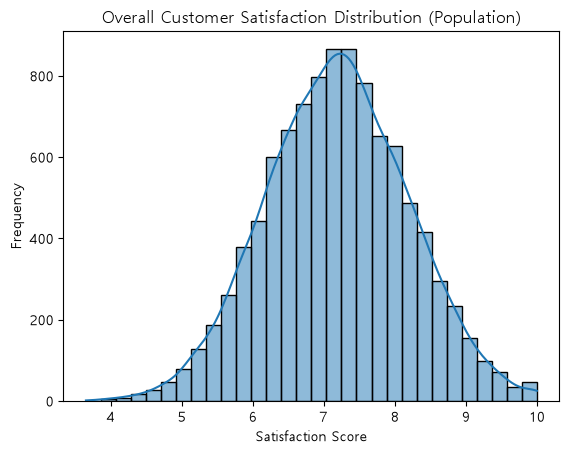

In [24]:
# 모집단 생성 (고객 만족도 10,000명)

np.random.seed(2025)
population = np.random.normal(loc=7.2, scale=1.0, size=10000)
population = np.clip(population, 1, 10)
# 모집단 시각화
sns.histplot(population, bins=30, kde=True)
plt.title("Overall Customer Satisfaction Distribution (Population)")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.show()



**📌 아래를 수행해 보세요:**

- 모집단을 생성하고, 거기서 표본을 40명 뽑아 평균을 계산해봅시다.

- 표본 평균과 표준편차를 바탕으로 95% 신뢰구간을 계산해봅시다.

- 히스토그램을 그리고 신뢰구간을 시각화해봅시다.

- 이 결과를 어떻게 해석하고, 마케팅 전략에 활용할 수 있을지 생각해봅시다.

In [25]:
# [문제 5] Q1. 모집단에서 표본 40명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
np.random.seed(2025)

n = 40
sample = np.random.choice(population, size=n, replace=False)

sample_mean = sample.mean()
sample_std = sample.std(ddof=1)

print("표본 평균:", sample_mean)
print("표본 표준편차:", sample_std)

표본 평균: 7.225809160271515
표본 표준편차: 0.8972963814022722


In [26]:
# [문제 5] Q2. 표준오차(SE)를 구하고, t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
from scipy import stats

standard_error = sample_std / np.sqrt(n)

confidence = 0.95
df = n - 1
t_critical = stats.t.ppf((1 + confidence) / 2, df=df)

margin_of_error = t_critical * standard_error
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

population_mean = population.mean()
print("모집단 평균:", population_mean)

print("표준오차(SE):", standard_error)
print("t-critical 값:", t_critical)
print(f"95% 신뢰구간: ({ci_lower:.3f}, {ci_upper:.3f})")

모집단 평균: 7.189692487302789
표준오차(SE): 0.14187501507291653
t-critical 값: 2.022690920036761
95% 신뢰구간: (6.939, 7.513)


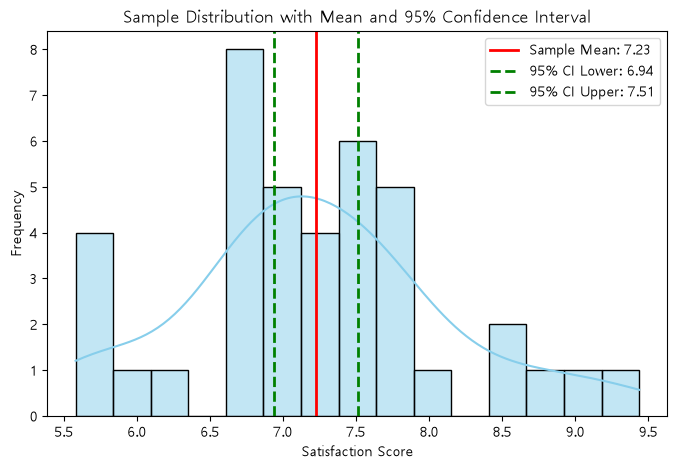

In [27]:
# [문제 5] Q3. 표본 데이터의 히스토그램을 그리고, 평균 및 신뢰구간을 함께 시각화해봅시다.


plt.figure(figsize=(8, 5))

sns.histplot(sample, bins=15, kde=True, color='skyblue')

plt.axvline(sample_mean, color='red', linestyle='-', linewidth=2, label=f'Sample Mean: {sample_mean:.2f}')
plt.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label=f'95% CI Lower: {ci_lower:.2f}')
plt.axvline(ci_upper, color='green', linestyle='--', linewidth=2, label=f'95% CI Upper: {ci_upper:.2f}')

plt.title("Sample Distribution with Mean and 95% Confidence Interval")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [28]:
# [문제 5] Q4. 신뢰구간의 결과에 따라 어떤 구체적인 마케팅 전략을 세울 수 있을까요?
# 여기에 의견을 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- 신뢰구간은 몇 점에서 몇 점 사이인가요?

- 이 구간은 전체 모집단 평균을 포함하고 있나요?

- 이 결과를 바탕으로 고객 만족도가 충분히 높다고 말할 수 있을까요?

- 만약 신뢰구간이 너무 넓게 나왔다면, 그 이유는 무엇이고 어떻게 개선할 수 있을까요?

In [29]:
# [문제 5] 데이터를 어떻게 읽을까요?
# 신뢰구간은  (6.94, 7.51)이고 폭이 약 0.57로 꽤 좁은 편입니다. 
# 이건 우리가 한 추정이 상당히 안정적이라는 의미입니다. 이걸 마케팅에 활용하면
# 신뢰구간이 7점 이상을 포함하는 것은 전반적으로 만족도가 양호하기 때문에 기존 고객을 유지하는 전략에 집중할 수 있습니다.
# 또한 신뢰구간의 폭이 좁기 때문에 이 추정치를 믿고 의사결정에 활용해도 리스크가 낮습니다.
# 만약 우리의 목표가 ‘만족도 7.0 이상 유지’라면, 신뢰구간이 7.0보다 살짝 높은 수준이기 때문에 
# 대규모 개선이 아닌 소폭 개선을 중심으로 한 캠페인을 고려할 수 있습니다.

# 만약 신뢰구간이 너무 넓게 나왔다면
# 표본의 크기가 작을 수 있습니다. SE = σ/√n 이므로, n이 작으면 SE가 커지고 신뢰구간도 넒어집니다. 
# 표본의 변동성이 클 수 있습니다. 즉, 표준편차가 크다는 것이죠 그렇다면 SE상승으로 이어지고 이 역시 신뢰구간의 상승으로 이어집니다. 
# 신뢰수준을 너무 높게 잡아도 신뢰구간이 넓어질 수 있습니다.
# 마지막으로 표본이 모집단을 잘 대표하지 못할 때는 실제 변동성보다 더 크게 나타날 수 있습니다.

# 개선 방법으로는 위 사항을 조절하면 됩니다.
# 표본의 크기를 늘리거나
#표본 추출 방법을 개선하거나
# 신뢰수준을 현실적으로 조정하거나
# 이상치를 점검할 수 있습니다.